In [1]:
import tensorflow_probability as tfp
import tensorflow as tf

from tensorflow.keras import backend as K

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

from importlib import reload

In [2]:
import sys
import os
sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE.layers as layers
from tools_for_VAE import utils, vae_functions, generator, model

W0624 12:22:37.883111 140227199625024 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:65: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
reload(utils)

<module 'tools_for_VAE.utils' from '../../scripts/tools_for_VAE/tools_for_VAE/utils.py'>

In [4]:
from tensorflow.keras.layers import Input, Dense, Lambda, Layer, Add, Multiply, Reshape, Flatten, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, Input, Dense, Dropout, MaxPool2D, Flatten,  Reshape, UpSampling2D, Cropping2D, Conv2DTranspose, PReLU, Concatenate, Lambda, BatchNormalization, concatenate, LeakyReLU

In [5]:
tfd = tfp.distributions

In [6]:
import tensorflow

# Parameters

In [7]:
nb_of_bands = 6
batch_size = 100 

input_shape = (64, 64, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 3
filters = [32, 64, 128, 256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [4,5,6,7,8,9]

# Data loading

## Batchgenerator

In [8]:
images_dir = '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/isolated_galaxies/centered/'
list_of_samples = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test')) if x.endswith('.npy')]
list_of_samples_val = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'validation')) if x.endswith('.npy')]

In [9]:
test_generator = generator.BatchGenerator(bands, list_of_samples, total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='training',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None)


[BatchGenerator] total_sample_size =  10000
[BatchGenerator] len(list_of_samples) =  1


# Model Deterministic

## Model architecture

In [10]:
reload(model)

<module 'tools_for_VAE.model' from '../../scripts/tools_for_VAE/tools_for_VAE/model.py'>

In [11]:
net_wo_ls = model.create_model_wo_ls(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0624 12:22:38.451768 140227199625024 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1630: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.


In [12]:
net_wo_ls.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 64, 64, 6)]       0         
_________________________________________________________________
batch_normalization (BatchNo (None, 64, 64, 6)         24        
_________________________________________________________________
conv2d (Conv2D)              (None, 64, 64, 32)        1760      
_________________________________________________________________
p_re_lu (PReLU)              (None, 64, 64, 32)        131072    
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 32, 32, 32)        9248      
_________________________________________________________________
p_re_lu_1 (PReLU)            (None, 32, 32, 32)        32768     
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 32, 32, 64)        18496 

In [13]:
loading_path = '/sps/lsst/users/barcelin/TFP/weights/test_deterministic_4_filters/loss/'

latest = tf.train.latest_checkpoint(loading_path)
net_wo_ls.load_weights(latest)

## Test

In [14]:
n = 10

In [15]:
test_data = np.zeros((n*batch_size, 64, 64, 6))
test_labels = np.zeros((n*batch_size, 3))

for i in range (n):
    test = test_generator.__getitem__(2)
    test_data[i*batch_size: (i+1)*batch_size] = test[0]
    test_labels[i*batch_size: (i+1)*batch_size] = test[1]

In [16]:
out = net_wo_ls(tf.cast(test_data, tf.float32))

In [17]:
# Compute ellipticities in [0,1], inverse function of the one in the generator
out_mean = np.zeros((n*batch_size,3))

out_mean[:,0] = K.get_value(out.mean())[:,0]#.numpy() for TF2
out_mean[:,1] = K.get_value(out.mean())[:,1]
out_mean[:,2] = K.get_value(out.mean())[:,2]
                    
                    
out_stddev = np.zeros((n*batch_size,3))

out_stddev[:,0] = K.get_value(out.stddev())[:,0]
out_stddev[:,1] = K.get_value(out.stddev())[:,1]
out_stddev[:,2] = K.get_value(out.stddev())[:,2]

### One sampling for 1000 images (ten batch)

Text(0.5, 1.0, '$z$')

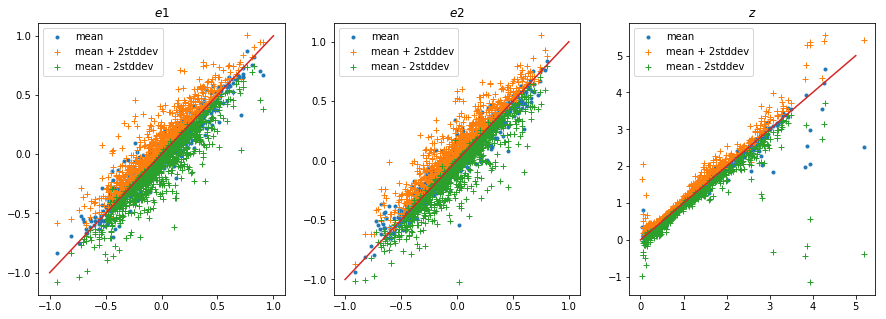

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(test_labels[:, 0], out_mean[:,0], '.', label = 'mean')
axes[0].plot(test_labels[:, 0], out_mean[:,0]+ 2*out_stddev[:,0], '+', label = 'mean + 2stddev')
axes[0].plot(test_labels[:, 0], out_mean[:,0]- 2*out_stddev[:,0], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
#axes[0].set_ylim(-0.5,6.5)
axes[0].set_title('$e1$')

axes[1].plot(test_labels[:, 1], out_mean[:,1], '.', label = 'mean')
axes[1].plot(test_labels[:, 1], out_mean[:,1]+ 2*out_stddev[:,1], '+', label = 'mean + 2stddev')
axes[1].plot(test_labels[:, 1], out_mean[:,1]- 2*out_stddev[:,1], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
#axes[1].set_ylim(-0.5,6.5)
axes[1].set_title('$e2$')

axes[2].plot(test_labels[:,2], out_mean[:,2], '.', label = 'mean')
axes[2].plot(test_labels[:,2], out_mean[:,2]+ 2*out_stddev[:,2], '+', label = 'mean + 2stddev')
axes[2].plot(test_labels[:,2], out_mean[:,2]- 2*out_stddev[:,2], '+', label = 'mean - 2stddev')
x = np.linspace(0,5)
axes[2].plot(x, x)
axes[2].legend()
#axes[2].set_ylim(-1,5.5)
axes[2].set_title('$z$')

### N samplings for 100 images (one batch)

In [19]:
N = 10
means_e1 = np.zeros((N,100))
stddevs_e1 = np.zeros((N,100))
means_e2 = np.zeros((N,100))
stddevs_e2 = np.zeros((N,100))
means_z = np.zeros((N,100))
stddevs_z = np.zeros((N,100))

outs = np.zeros((N,100))
for i in range (N):
    out = net_wo_ls(tf.cast(test_data[:100], tf.float32))
    outs[i] = K.get_value(out[:,0])#.numpy()
    means_e1[i] = K.get_value(out.mean())[:,0]#.numpy()
    stddevs_e1[i] = K.get_value(out.stddev())[:,0]
    means_e2[i] = K.get_value(out.mean())[:,1]
    stddevs_e2[i] = K.get_value(out.stddev())[:,1]
    means_z[i] = K.get_value(out.mean())[:,2]
    stddevs_z[i] = K.get_value(out.stddev())[:,2]

In [20]:
print(means_e1[:,1], stddevs_e1[:,1])

[0.00822236 0.00822236 0.00822236 0.00822236 0.00822236 0.00822236
 0.00822236 0.00822236 0.00822236 0.00822236] [0.00980463 0.00980463 0.00980463 0.00980463 0.00980463 0.00980463
 0.00980463 0.00980463 0.00980463 0.00980463]


As expected, mean and stddev are the same for a galaxy passed 100 times in the network.

#### Distribution

In [21]:
image_nb = 0

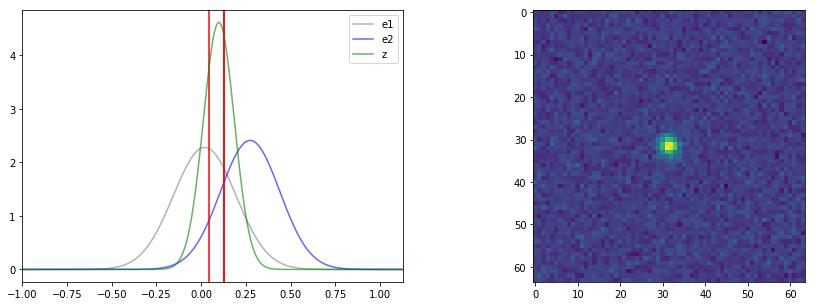

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
# mean_means = np.mean(means_e1[:,image_nb])
# mean_stddevs = np.mean(stddevs_e1[:,image_nb])
# axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,0], color = 'r')

axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
# mean_means = np.mean(means_e2[:,image_nb])
# mean_stddevs = np.mean(stddevs_e2[:,image_nb])
# axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,1], color = 'r')


axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
#mean_means = np.mean(means_z[:,image_nb])
#mean_stddevs = np.mean(stddevs_z[:,image_nb])
#axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'black', alpha = 1)    
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

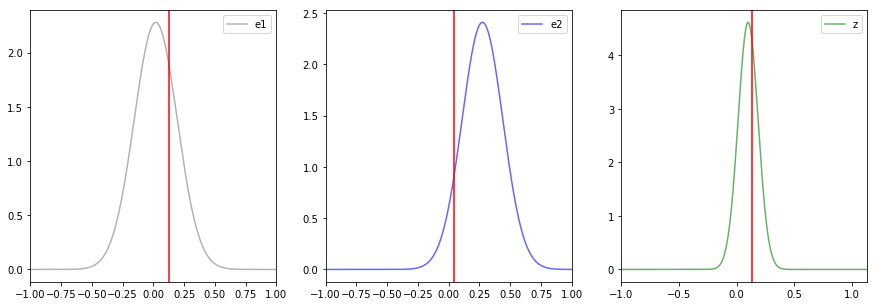

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
axes[0].axvline(test_labels[image_nb,0], color = 'r')
axes[0].set_xlim(-1,1)

axes[1].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
axes[1].axvline(test_labels[image_nb,1], color = 'r')
axes[1].set_xlim(-1,1)

axes[2].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
axes[2].axvline(test_labels[image_nb,2], color = 'r')
axes[2].set_xlim(-1,test_labels[image_nb,2]+1)

#axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()
axes[1].legend()
axes[2].legend()

### Other example

In [24]:
image_nb = 1

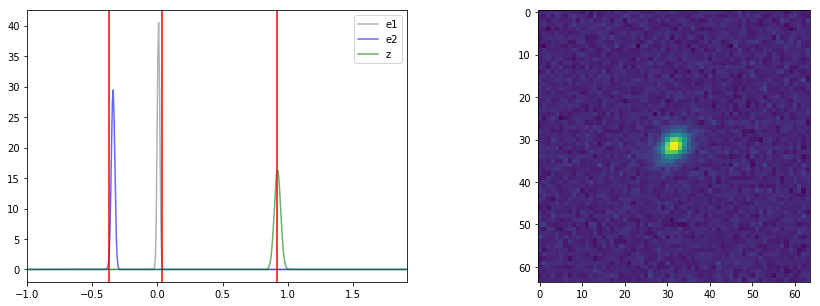

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
axes[0].axvline(test_labels[image_nb,0], color = 'r')

axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
axes[0].axvline(test_labels[image_nb,1], color = 'r')


axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

# Model full probabilistic - Flipout

Note: for the model to work and train it needs to be train with TF1 (for the K-tied - https://arxiv.org/pdf/2002.02655.pdf - distribution to be used).
    
Consequently some changes are done below to use it with TF1.

## Model architecture

In [26]:
reload(model)

<module 'tools_for_VAE.model' from '../../scripts/tools_for_VAE/tools_for_VAE/model.py'>

In [27]:
net_prob = model.create_model_full_prob_flipout(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0624 12:25:20.642013 140227199625024 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_probability/python/layers/util.py:104: Layer.add_variable (from tensorflow.python.keras.engine.base_layer) is deprecated and will be removed in a future version.
Instructions for updating:
Please use `layer.add_weight` method instead.
W0624 12:25:21.836295 140227199625024 module_wrapper.py:137] From ../../scripts/tools_for_VAE/tools_for_VAE/ktied_distribution.py:45: The name tf.keras.initializers.TruncatedNormal is deprecated. Please use tf.compat.v1.keras.initializers.TruncatedNormal instead.

W0624 12:25:21.837322 140227199625024 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/keras/initializers.py:94: calling TruncatedNormal.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for 

[4096, 9]
Tensor("dense_flipout/Size:0", shape=(), dtype=int32)


In [28]:
net_prob.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 64, 64, 6)]       0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 64, 64, 6)         24        
_________________________________________________________________
conv2d_flipout (Conv2DFlipou (None, 64, 64, 32)        3488      
_________________________________________________________________
p_re_lu_8 (PReLU)            (None, 64, 64, 32)        131072    
_________________________________________________________________
conv2d_flipout_1 (Conv2DFlip (None, 32, 32, 32)        18464     
_________________________________________________________________
p_re_lu_9 (PReLU)            (None, 32, 32, 32)        32768     
_________________________________________________________________
conv2d_flipout_2 (Conv2DFlip (None, 32, 32, 64)        3692

In [40]:
loading_path = '/sps/lsst/users/barcelin/TFP/weights/test_flipout_4_filters/mse/' #_3_2 with only 4 kernels and tanh+PReLU activation 

latest = tf.train.latest_checkpoint(loading_path)
net_prob.load_weights(latest)

In [41]:
#net_prob.load_weights('/sps/lsst/users/barcelin/TFP/weights/test_prob_flipout/loss/weights_noisy_v4.109-2679.26.ckpt')

## Test

In [42]:
n = 10

In [43]:
test_data = np.zeros((n*batch_size, 64, 64, 6))
test_labels = np.zeros((n*batch_size, 3))

for i in range (n):
    test = test_generator.__getitem__(2)
    test_data[i*batch_size: (i+1)*batch_size] = test[0]
    test_labels[i*batch_size: (i+1)*batch_size] = test[1]

In [44]:
test_data.shape

(1000, 64, 64, 6)

Small changes because TF1 for training of Bayesian Deep Neural nets

In [45]:
out = net_prob(tf.cast(test_data, tf.float32))

In [46]:
# Compute ellipticities in [0,1], inverse function of the one in the generator
out_mean = np.zeros((n*batch_size,3))

out_mean[:,0] = K.get_value(out.mean())[:,0]# out.mean().numpy()[:,0]#np.log(out.mean().numpy()[:,0]/2)
out_mean[:,1] = K.get_value(out.mean())[:,1]#np.log(out.mean().numpy()[:,1]/2)
out_mean[:,2] = K.get_value(out.mean())[:,2]
                    
                    
out_stddev = np.zeros((n*batch_size,3))

out_stddev[:,0] = K.get_value(out.stddev())[:,0]#np.log(out.stddev().numpy()[:,0]/2)
out_stddev[:,1] = K.get_value(out.stddev())[:,1]#np.log(out.stddev().numpy()[:,1]/2)
out_stddev[:,2] = K.get_value(out.stddev())[:,2]

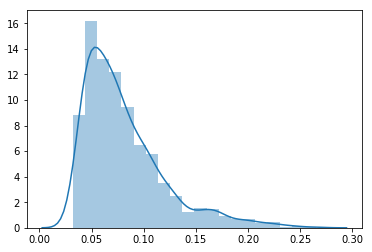

In [47]:
sns.distplot(out_stddev[:,0], bins = 20)

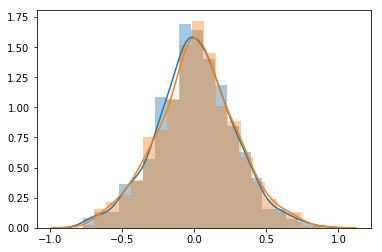

In [48]:
sns.distplot(out_mean[:,0], bins = 20)
sns.distplot(test_labels[:, 0], bins = 20)

### One sampling for 1000 images (ten batch)

Text(0.5, 1.0, '$z$')

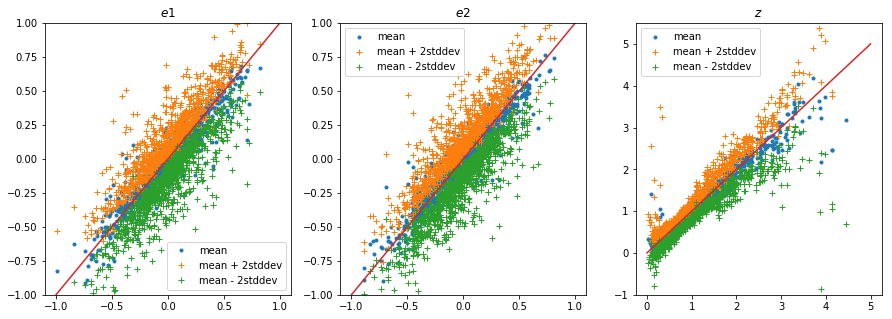

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(test_labels[:, 0], out_mean[:,0], '.', label = 'mean')
axes[0].plot(test_labels[:, 0], out_mean[:,0]+ 2*out_stddev[:,0], '+', label = 'mean + 2stddev')
axes[0].plot(test_labels[:, 0], out_mean[:,0]- 2*out_stddev[:,0], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].plot(test_labels[:, 1], out_mean[:,1], '.', label = 'mean')
axes[1].plot(test_labels[:, 1], out_mean[:,1]+ 2*out_stddev[:,1], '+', label = 'mean + 2stddev')
axes[1].plot(test_labels[:, 1], out_mean[:,1]- 2*out_stddev[:,1], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

axes[2].plot(test_labels[:,2], out_mean[:,2], '.', label = 'mean')
axes[2].plot(test_labels[:,2], out_mean[:,2]+ 2*out_stddev[:,2], '+', label = 'mean + 2stddev')
axes[2].plot(test_labels[:,2], out_mean[:,2]- 2*out_stddev[:,2], '+', label = 'mean - 2stddev')
x = np.linspace(0,5)
axes[2].plot(x, x)
axes[2].legend()
axes[2].set_ylim(-1,5.5)
axes[2].set_title('$z$')

### N samplings for 100 images (one batch)

In [62]:
N = 10
means_e1 = np.zeros((N,100))
stddevs_e1 = np.zeros((N,100))
means_e2 = np.zeros((N,100))
stddevs_e2 = np.zeros((N,100))
means_z = np.zeros((N,100))
stddevs_z = np.zeros((N,100))

outs = np.zeros((N,100))
for i in range (N):
    print(i)
    out = net_prob(tf.cast(test_data[:100], tf.float32))
    outs[i] = K.get_value(out[:,0])#.numpy()
    means_e1[i] = K.get_value(out.mean())[:,0]#out.mean().numpy()
    stddevs_e1[i] = K.get_value(out.stddev())[:,0]
    means_e2[i] = K.get_value(out.mean())[:,1]
    stddevs_e2[i] = K.get_value(out.stddev())[:,1]
    means_z[i] = K.get_value(out.mean())[:,2]
    stddevs_z[i] = K.get_value(out.stddev())[:,2]

0
1
2
3
4
5
6
7
8
9


#### 1 sampling : distribution of e1, e2 and z

In [63]:
image_nb = 0

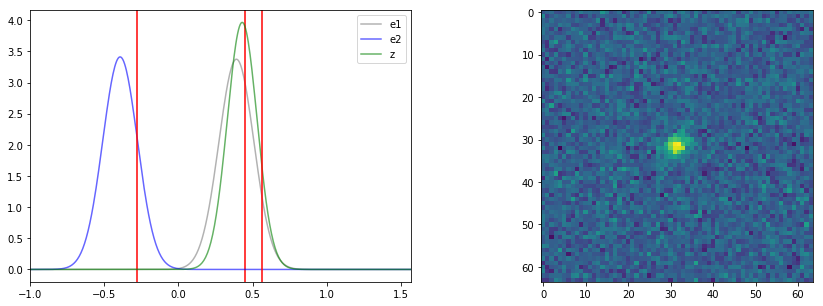

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
axes[0].axvline(test_labels[image_nb,0], color = 'r')

axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
axes[0].axvline(test_labels[image_nb,1], color = 'r')


axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

#### 10 sampling : distribution of e1, e2 and z

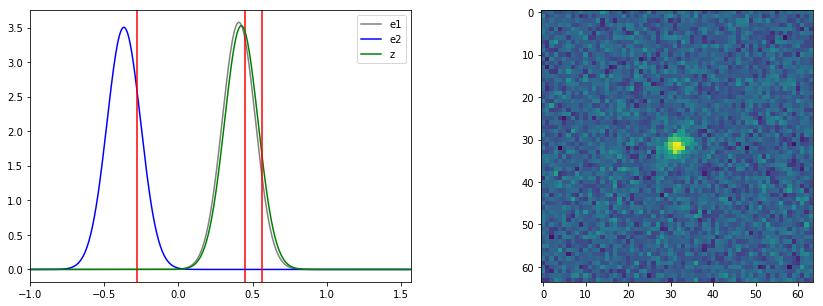

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3)
#    if i == len(means_e1)-1 : 
#        axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3 , label = 'e1')
mean_means = np.mean(means_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'grey', alpha = 1, label = 'e1')    
axes[0].axvline(test_labels[image_nb,0], color = 'r')

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3)
#    if i == len(means_e1)-1:
#        axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2')
mean_means = np.mean(means_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_e2[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'b', alpha = 1, label = 'e2')    
axes[0].axvline(test_labels[image_nb,1], color = 'r')

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3)
#    if i == len(means_e1)-1:
#        axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3, label = 'z')
mean_means = np.mean(means_z[:,image_nb])
mean_stddevs = np.mean(stddevs_z[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'z')    
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

### Other example

In [66]:
image_nb = 1

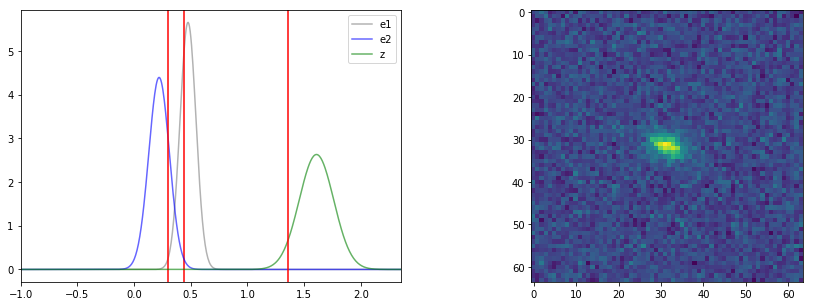

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
axes[0].axvline(test_labels[image_nb,0], color = 'r')

axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
axes[0].axvline(test_labels[image_nb,1], color = 'r')


axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

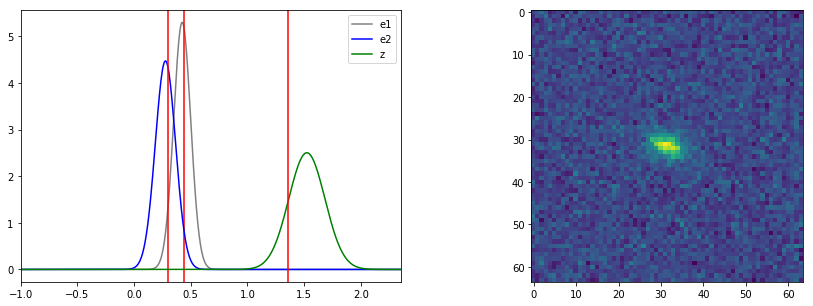

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)

mean_means = np.mean(means_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'grey', alpha = 1, label = 'e1')    
axes[0].axvline(test_labels[image_nb,0], color = 'r')

mean_means = np.mean(means_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_e2[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'b', alpha = 1, label = 'e2')    
axes[0].axvline(test_labels[image_nb,1], color = 'r')

mean_means = np.mean(means_z[:,image_nb])
mean_stddevs = np.mean(stddevs_z[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'z')    
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

# Model full probabilistic - Reparametrization trick 

## Model architecture

In [ ]:
reload(model)

In [49]:
net_prob_rt = model.create_model_full_prob_rt(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

[4096, 9]
Tensor("dense_reparameterization/Size:0", shape=(), dtype=int32)


In [50]:
net_prob_rt.summary()

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 64, 64, 6)]       0         
_________________________________________________________________
batch_normalization_2 (Batch (None, 64, 64, 6)         24        
_________________________________________________________________
conv2d_reparameterization (C (None, 64, 64, 32)        3488      
_________________________________________________________________
p_re_lu_16 (PReLU)           (None, 64, 64, 32)        131072    
_________________________________________________________________
conv2d_reparameterization_1  (None, 32, 32, 32)        18464     
_________________________________________________________________
p_re_lu_17 (PReLU)           (None, 32, 32, 32)        32768     
_________________________________________________________________
conv2d_reparameterization_2  (None, 32, 32, 64)        3692

In [51]:
loading_path = '/sps/lsst/users/barcelin/TFP/weights/test_rt_4_filters/mse/' #_3_2 with only 4 kernels and tanh+PReLU activation 

latest = tf.train.latest_checkpoint(loading_path)
net_prob_rt.load_weights(latest)

## Test

In [100]:
n = 10

test_data = np.zeros((n*batch_size, 64, 64, 6))
test_labels = np.zeros((n*batch_size, 3))

for i in range (n):
    test = test_generator.__getitem__(2)
    test_data[i*batch_size: (i+1)*batch_size] = test[0]
    test_labels[i*batch_size: (i+1)*batch_size] = test[1]

In [101]:
test_data.shape

(1000, 64, 64, 6)

Small changes because TF1 for training of Bayesian Deep Neural nets

In [90]:
out = net_prob_rt(tf.cast(test_data, tf.float32))

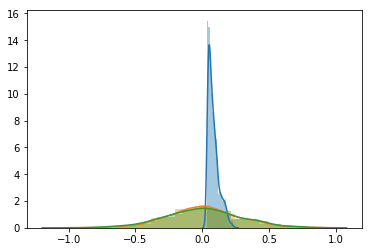

In [91]:
# Compute ellipticities in [0,1], inverse function of the one in the generator
out_mean = np.zeros((n*batch_size,3))

out_mean[:,0] = K.get_value(out.mean())[:,0]# out.mean().numpy()[:,0]#np.log(out.mean().numpy()[:,0]/2)
out_mean[:,1] = K.get_value(out.mean())[:,1]#np.log(out.mean().numpy()[:,1]/2)
out_mean[:,2] = K.get_value(out.mean())[:,2]
                    
                    
out_stddev = np.zeros((n*batch_size,3))

out_stddev[:,0] = K.get_value(out.stddev())[:,0]#np.log(out.stddev().numpy()[:,0]/2)
out_stddev[:,1] = K.get_value(out.stddev())[:,1]#np.log(out.stddev().numpy()[:,1]/2)
out_stddev[:,2] = K.get_value(out.stddev())[:,2]

sns.distplot(out_stddev[:,0], bins = 20)

sns.distplot(out_mean[:,0], bins = 20)
sns.distplot(test_labels[:, 0], bins = 20)

### One sampling for 1000 images (ten batch)

Text(0.5, 1.0, '$z$')

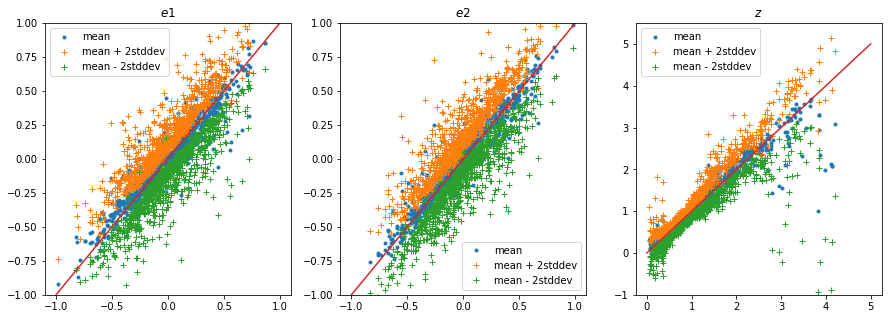

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(test_labels[:, 0], out_mean[:,0], '.', label = 'mean')
axes[0].plot(test_labels[:, 0], out_mean[:,0]+ 2*out_stddev[:,0], '+', label = 'mean + 2stddev')
axes[0].plot(test_labels[:, 0], out_mean[:,0]- 2*out_stddev[:,0], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].plot(test_labels[:, 1], out_mean[:,1], '.', label = 'mean')
axes[1].plot(test_labels[:, 1], out_mean[:,1]+ 2*out_stddev[:,1], '+', label = 'mean + 2stddev')
axes[1].plot(test_labels[:, 1], out_mean[:,1]- 2*out_stddev[:,1], '+', label = 'mean - 2stddev')
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

axes[2].plot(test_labels[:,2], out_mean[:,2], '.', label = 'mean')
axes[2].plot(test_labels[:,2], out_mean[:,2]+ 2*out_stddev[:,2], '+', label = 'mean + 2stddev')
axes[2].plot(test_labels[:,2], out_mean[:,2]- 2*out_stddev[:,2], '+', label = 'mean - 2stddev')
x = np.linspace(0,5)
axes[2].plot(x, x)
axes[2].legend()
axes[2].set_ylim(-1,5.5)
axes[2].set_title('$z$')

### N samplings for 100 images (one batch)

In [102]:
N = 10
means_e1 = np.zeros((N,100))
stddevs_e1 = np.zeros((N,100))
means_e2 = np.zeros((N,100))
stddevs_e2 = np.zeros((N,100))
means_z = np.zeros((N,100))
stddevs_z = np.zeros((N,100))

outs = np.zeros((N,100))
for i in range (N):
    print(i)
    out = net_prob_rt(tf.cast(test_data[:100], tf.float32))
    outs[i] = K.get_value(out[:,0])#.numpy()
    means_e1[i] = K.get_value(out.mean())[:,0]#out.mean().numpy()
    stddevs_e1[i] = K.get_value(out.stddev())[:,0]
    means_e2[i] = K.get_value(out.mean())[:,1]
    stddevs_e2[i] = K.get_value(out.stddev())[:,1]
    means_z[i] = K.get_value(out.mean())[:,2]
    stddevs_z[i] = K.get_value(out.stddev())[:,2]

0
1
2
3
4
5
6
7
8
9


#### 1 sampling : distribution of e1, e2 and z

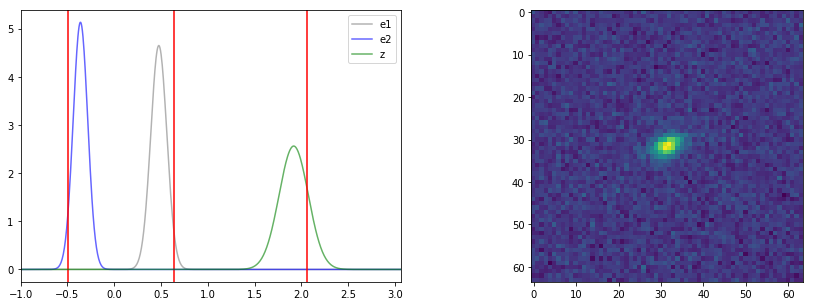

In [103]:
image_nb = 0

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
axes[0].axvline(test_labels[image_nb,0], color = 'r')

axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
axes[0].axvline(test_labels[image_nb,1], color = 'r')


axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

#### 10 sampling : distribution of e1, e2 and z

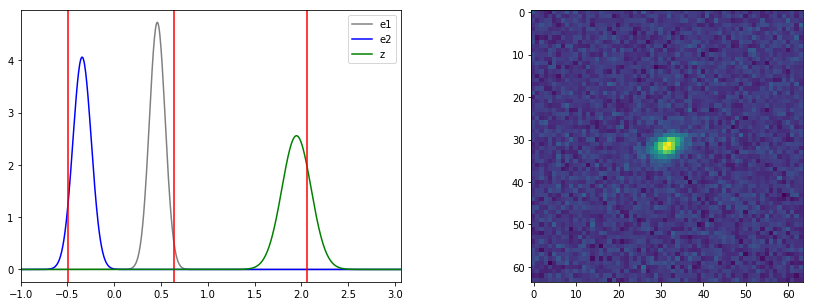

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3)
#    if i == len(means_e1)-1 : 
#        axes[0].plot(x, (1/(stddevs_e1[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[i,image_nb])/(2*stddevs_e1[i,image_nb]**2))), color = 'grey', alpha = 0.3 , label = 'e1')
mean_means = np.mean(means_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'grey', alpha = 1, label = 'e1')    
axes[0].axvline(test_labels[image_nb,0], color = 'r')

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3)
#    if i == len(means_e1)-1:
#        axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2')
mean_means = np.mean(means_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_e2[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'b', alpha = 1, label = 'e2')    
axes[0].axvline(test_labels[image_nb,1], color = 'r')

#for i in range (len(means_e1)):
#    axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3)
#    if i == len(means_e1)-1:
#        axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.3, label = 'z')
mean_means = np.mean(means_z[:,image_nb])
mean_stddevs = np.mean(stddevs_z[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'z')    
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

In [128]:
print(np.around(1.44), np.floor(1.44))


1.0 1.0


### Other example

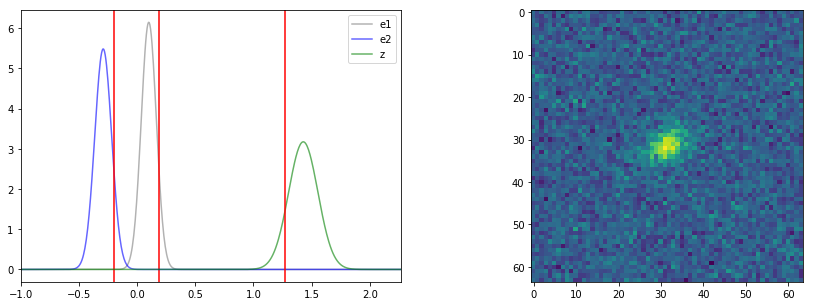

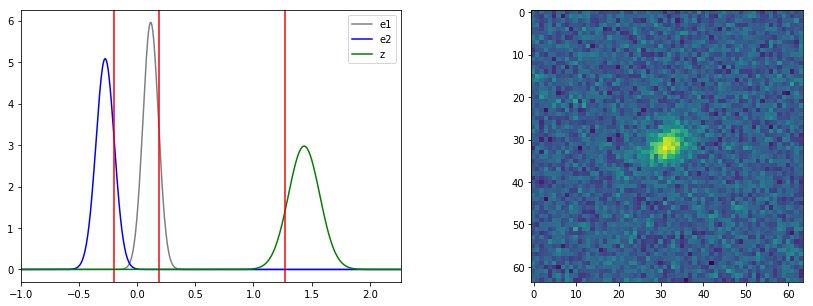

In [105]:
image_nb = 1

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)


axes[0].plot(x, (1/(stddevs_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e1[0,image_nb])/(2*stddevs_e1[0,image_nb]**2))), color = 'grey', alpha = 0.6, label = 'e1')
axes[0].axvline(test_labels[image_nb,0], color = 'r')

axes[0].plot(x, (1/(stddevs_e2[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_e2[i,image_nb])/(2*stddevs_e2[i,image_nb]**2))), color = 'b', alpha = 0.6, label= 'e2')
axes[0].axvline(test_labels[image_nb,1], color = 'r')


axes[0].plot(x, (1/(stddevs_z[i,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_z[i,image_nb])/(2*stddevs_z[i,image_nb]**2))), color = 'green', alpha = 0.6, label= 'z')
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(-1,5, 1000)

mean_means = np.mean(means_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'grey', alpha = 1, label = 'e1')    
axes[0].axvline(test_labels[image_nb,0], color = 'r')

mean_means = np.mean(means_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_e2[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'b', alpha = 1, label = 'e2')    
axes[0].axvline(test_labels[image_nb,1], color = 'r')

mean_means = np.mean(means_z[:,image_nb])
mean_stddevs = np.mean(stddevs_z[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'z')    
axes[0].axvline(test_labels[image_nb,2], color = 'r')
axes[0].set_xlim(-1,test_labels[image_nb,2]+1)

axes[1].imshow(test_data[image_nb,:,:,2])
axes[0].legend()

# Comparison of deterministic/probabilistic networks

## One sampling for 1000 images (ten batch)

In [52]:
n = 10

In [53]:
test_data = np.zeros((n*batch_size, 64, 64, 6))
test_labels = np.zeros((n*batch_size, 3))

for i in range (n):
    test = test_generator.__getitem__(2)
    test_data[i*batch_size: (i+1)*batch_size] = test[0]
    test_labels[i*batch_size: (i+1)*batch_size] = test[1]

test_data.shape

(1000, 64, 64, 6)

In [54]:
#out_with = net(tf.cast(test_data, tf.float32))
out_without = net_wo_ls(tf.cast(test_data, tf.float32))
out_prob = net_prob(tf.cast(test_data, tf.float32))
out_prob_rt = net_prob_rt(tf.cast(test_data, tf.float32))

E1

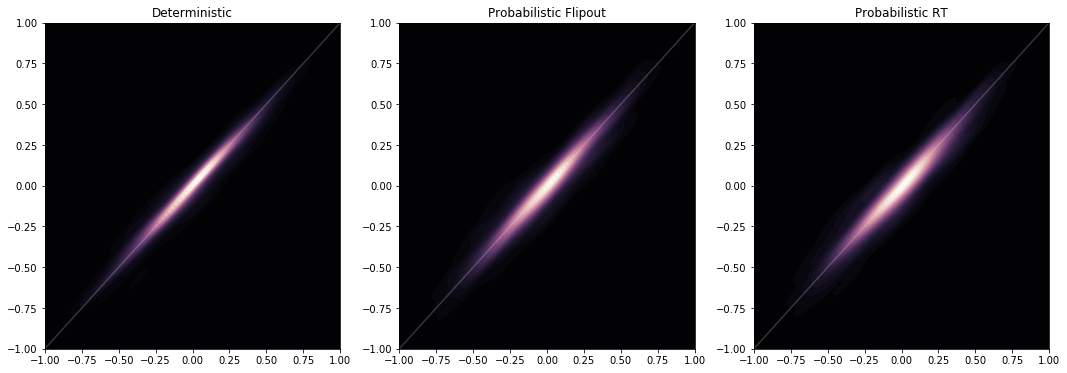

In [55]:
f, ax = plt.subplots(1,3,figsize=(18, 6))
cmap = sns.cubehelix_palette(as_cmap=True, dark=0, light=1, reverse=True)
#sns.kdeplot(test_labels[:, 0], K.get_value(out_with.mean())[:,0], cmap=cmap, n_levels=60, shade=True, ax = ax[0])
#ax[0].set_title('With latent space')
#x = np.linspace(-10,10,1000)
#ax[0].set_xlim(-1,1)
#ax[0].set_ylim(-1,1)
#ax[0].plot(x,x, color = 'white', alpha = 0.2)

sns.kdeplot(test_labels[:, 0], K.get_value(out_without.mean())[:,0], cmap=cmap, n_levels=60, shade=True, ax = ax[0])
ax[0].set_title('Deterministic')
x = np.linspace(-10,10,1000)
ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1,1)
ax[0].plot(x,x, color = 'white', alpha = 0.2)

sns.kdeplot(test_labels[:, 0], K.get_value(out_prob.mean())[:,0], cmap=cmap, n_levels=60, shade=True, ax = ax[1])
ax[1].set_title('Probabilistic Flipout')
x = np.linspace(-10,10,1000)
ax[1].set_xlim(-1,1)
ax[1].set_ylim(-1,1)
ax[1].plot(x,x, color = 'white', alpha = 0.2)

sns.kdeplot(test_labels[:, 0], K.get_value(out_prob.mean())[:,0], cmap=cmap, n_levels=60, shade=True, ax = ax[2])
ax[2].set_title('Probabilistic RT')
x = np.linspace(-10,10,1000)
ax[2].set_xlim(-1,1)
ax[2].set_ylim(-1,1)
ax[2].plot(x,x, color = 'white', alpha = 0.2)

E2

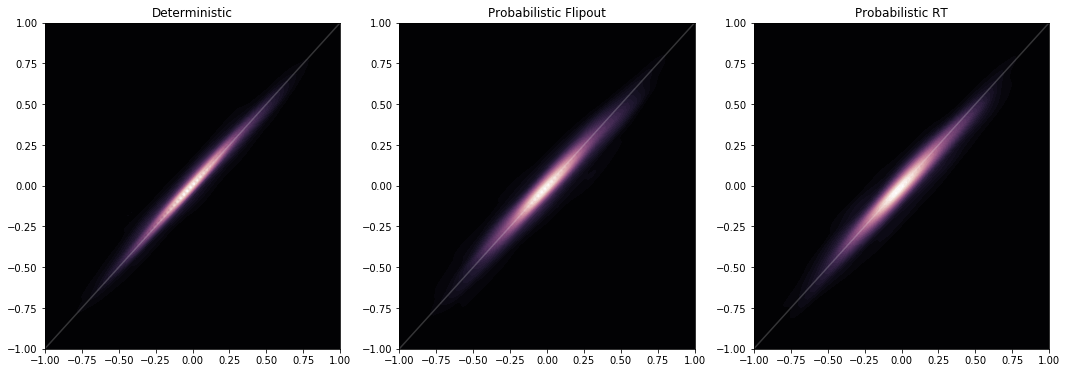

In [56]:
f, ax = plt.subplots(1,3,figsize=(18, 6))
cmap = sns.cubehelix_palette(as_cmap=True, dark=0, light=1, reverse=True)

sns.kdeplot(test_labels[:, 1], K.get_value(out_without.mean())[:,1], cmap=cmap, n_levels=60, shade=True, ax = ax[0])
ax[0].set_title('Deterministic')
x = np.linspace(-10,10,1000)
ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1,1)
ax[0].plot(x,x, color = 'white', alpha = 0.2)

sns.kdeplot(test_labels[:, 1], K.get_value(out_prob.mean())[:,1], cmap=cmap, n_levels=60, shade=True, ax = ax[1])
ax[1].set_title('Probabilistic Flipout')
x = np.linspace(-10,10,1000)
ax[1].set_xlim(-1,1)
ax[1].set_ylim(-1,1)
ax[1].plot(x,x, color = 'white', alpha = 0.2)

sns.kdeplot(test_labels[:, 1], K.get_value(out_prob.mean())[:,1], cmap=cmap, n_levels=60, shade=True, ax = ax[2])
ax[2].set_title('Probabilistic RT')
x = np.linspace(-10,10,1000)
ax[2].set_xlim(-1,1)
ax[2].set_ylim(-1,1)
ax[2].plot(x,x, color = 'white', alpha = 0.2)

Redshift

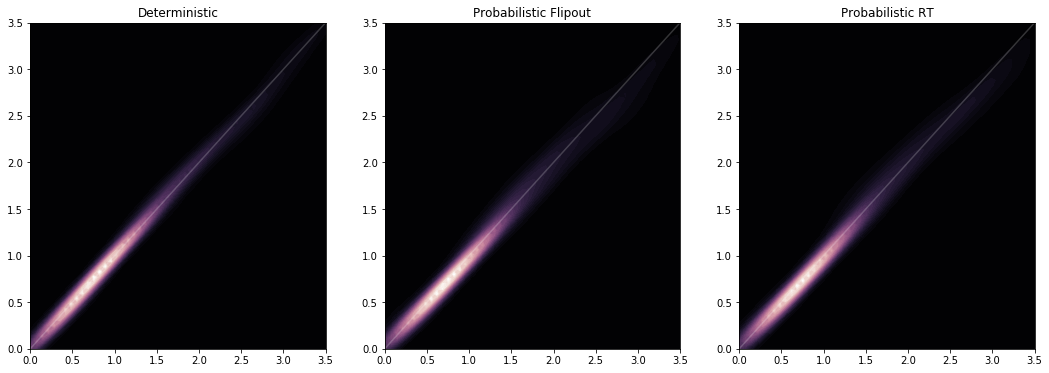

In [57]:
f, ax = plt.subplots(1,3,figsize=(18, 6))
cmap = sns.cubehelix_palette(as_cmap=True, dark=0, light=1, reverse=True)

sns.kdeplot(test_labels[:, 2], K.get_value(out_without.mean())[:,2], cmap=cmap, n_levels=60, shade=True, ax = ax[0])
ax[0].set_title('Deterministic')
x = np.linspace(-10,10,1000)
ax[0].set_xlim(0,3.5)
ax[0].set_ylim(0,3.5)
ax[0].plot(x,x, color = 'white', alpha = 0.2)

sns.kdeplot(test_labels[:, 2], K.get_value(out_prob.mean())[:,2], cmap=cmap, n_levels=60, shade=True, ax = ax[1])
ax[1].set_title('Probabilistic Flipout')
x = np.linspace(-10,10,1000)
ax[1].set_xlim(0,3.5)
ax[1].set_ylim(0,3.5)
ax[1].plot(x,x, color = 'white', alpha = 0.2)

sns.kdeplot(test_labels[:, 2], K.get_value(out_prob.mean())[:,2], cmap=cmap, n_levels=60, shade=True, ax = ax[2])
ax[2].set_title('Probabilistic RT')
x = np.linspace(-10,10,1000)
ax[2].set_xlim(0,3.5)
ax[2].set_ylim(0,3.5)
ax[2].plot(x,x, color = 'white', alpha = 0.2)

### N samplings for 100 images (one batch)

In [58]:
N = 10

means_without_e1 = np.zeros((1,100))
stddevs_without_e1 = np.zeros((1,100))
means_without_e2 = np.zeros((1,100))
stddevs_without_e2 = np.zeros((1,100))
means_without_z = np.zeros((1,100))
stddevs_without_z = np.zeros((1,100))

means_prob_e1 = np.zeros((N,100))
stddevs_prob_e1 = np.zeros((N,100))
means_prob_e2 = np.zeros((N,100))
stddevs_prob_e2 = np.zeros((N,100))
means_prob_z = np.zeros((N,100))
stddevs_prob_z = np.zeros((N,100))

means_prob_rt_e1 = np.zeros((N,100))
stddevs_prob_rt_e1 = np.zeros((N,100))
means_prob_rt_e2 = np.zeros((N,100))
stddevs_prob_rt_e2 = np.zeros((N,100))
means_prob_rt_z = np.zeros((N,100))
stddevs_prob_rt_z = np.zeros((N,100))

outs_with = np.zeros((N,100))
outs_prob = np.zeros((N,100))
outs_prob_rt = np.zeros((N,100))
for i in range (N):
    print(i)
    out_prob = net_prob(tf.cast(test_data[:100], tf.float32))
    out_prob_rt = net_prob(tf.cast(test_data[:100], tf.float32))

    outs_prob[i] = K.get_value(out_prob[:,0])
    means_prob_e1[i] = K.get_value(out_prob.mean())[:,0]
    stddevs_prob_e1[i] = K.get_value(out_prob.stddev())[:,0]
    means_prob_e2[i] = K.get_value(out_prob.mean())[:,1]
    stddevs_prob_e2[i] = K.get_value(out_prob.stddev())[:,1]
    means_prob_z[i] = K.get_value(out_prob.mean())[:,2]
    stddevs_prob_z[i] = K.get_value(out_prob.stddev())[:,2]
    
    outs_prob_rt[i] = K.get_value(out_prob_rt[:,0])
    means_prob_rt_e1[i] = K.get_value(out_prob_rt.mean())[:,0]
    stddevs_prob_rt_e1[i] = K.get_value(out_prob_rt.stddev())[:,0]
    means_prob_rt_e2[i] = K.get_value(out_prob_rt.mean())[:,1]
    stddevs_prob_rt_e2[i] = K.get_value(out_prob_rt.stddev())[:,1]
    means_prob_rt_z[i] = K.get_value(out_prob_rt.mean())[:,2]
    stddevs_prob_rt_z[i] = K.get_value(out_prob_rt.stddev())[:,2]

0
1
2
3
4
5
6
7
8
9


In [59]:
out_without = net_wo_ls(tf.cast(test_data[:100], tf.float32))
means_without_e1[0] = K.get_value(out_without.mean())[:,0]
stddevs_without_e1[0] = K.get_value(out_without.stddev())[:,0]
means_without_e2[0] = K.get_value(out_without.mean())[:,1]
stddevs_without_e2[0] = K.get_value(out_without.stddev())[:,1]
means_without_z[0] = K.get_value(out_without.mean())[:,2]
stddevs_without_z[0] = K.get_value(out_without.stddev())[:,2]

Distribution after 10 samplings

e1: 0.5034005045890808 e0: -0.2287774533033371 redshift: 0.8062000274658203


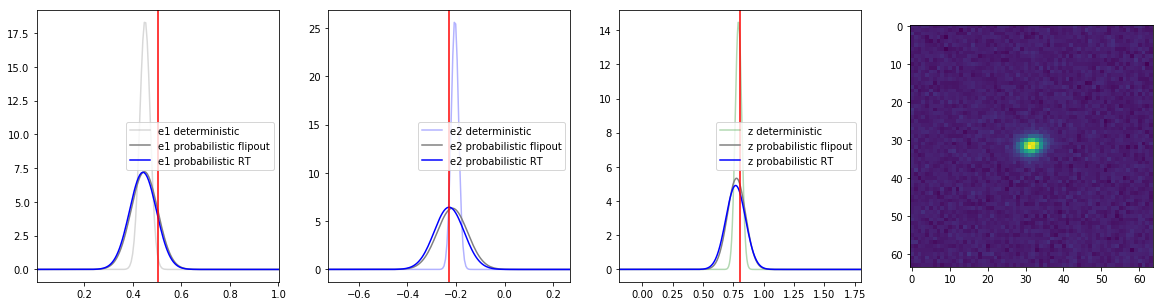

In [62]:
image_nb = 0

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.linspace(-1,5, 1000)

# E1
axes[0].plot(x, (1/(stddevs_without_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e1[0,image_nb])/(2*stddevs_without_e1[0,image_nb]**2))), color = 'grey', alpha = 0.3, label = 'e1 deterministic')

#mean_means = np.mean(means_without_e1[:,image_nb])
#mean_stddevs = np.mean(stddevs_with_e1[:,image_nb])
#axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'e1 deterministic')    

mean_means_prob = np.mean(means_prob_e1[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'e1 probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_e1[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'e1 probabilistic RT')    


axes[0].axvline(test_labels[image_nb,0], color = 'r')

# E2
axes[1].plot(x, (1/(stddevs_without_e2[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e2[0,image_nb])/(2*stddevs_without_e2[0,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2 deterministic')

#mean_means = np.mean(means_with_e2[:,image_nb])
#mean_stddevs = np.mean(stddevs_with_e2[:,image_nb])
#axes[1].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'e2 deterministic')    

mean_means_prob = np.mean(means_prob_e2[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'e2 probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_e2[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'e2 probabilistic RT')    

axes[1].axvline(test_labels[image_nb,1], color = 'r')

# Redshift
axes[2].plot(x, (1/(stddevs_without_z[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_z[0,image_nb])/(2*stddevs_without_z[0,image_nb]**2))), color = 'green', alpha = 0.3, label= 'z deterministic')

#mean_means = np.mean(means_with_z[:,image_nb])
#mean_stddevs = np.mean(stddevs_with_z[:,image_nb])
#axes[2].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label= 'z deterministic')    

mean_means_prob = np.mean(means_prob_z[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'z probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_z[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'z probabilistic RT')    

axes[2].axvline(test_labels[image_nb,2], color = 'r')

# Limit of graphs
axes[0].set_xlim(test_labels[image_nb,0]-0.5,test_labels[image_nb,0]+0.5)
axes[1].set_xlim(test_labels[image_nb,1]-0.5,test_labels[image_nb,1]+0.5)
axes[2].set_xlim(test_labels[image_nb,2]-1,test_labels[image_nb,2]+1)

axes[3].imshow(test_data[image_nb,:,:,2])
axes[0].legend()
axes[1].legend()
axes[2].legend()

print('e1: '+str(test_labels[image_nb,0]), 'e0: '+str(test_labels[image_nb,1]),'redshift: ' +str(test_labels[image_nb,2]))

e1: 0.5034005045890808 e0: -0.2287774533033371 redshift: 0.8062000274658203


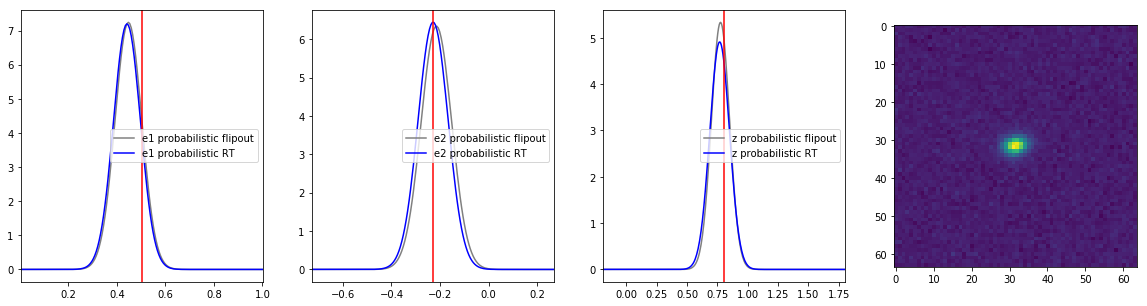

In [63]:
image_nb = 0

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.linspace(-1,5, 1000)

# E1
#axes[0].plot(x, (1/(stddevs_without_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e1[0,image_nb])/(2*stddevs_without_e1[0,image_nb]**2))), color = 'grey', alpha = 0.3, label = 'e1 deterministic')

#mean_means = np.mean(means_without_e1[:,image_nb])
#mean_stddevs = np.mean(stddevs_with_e1[:,image_nb])
#axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'e1 deterministic')    

mean_means_prob = np.mean(means_prob_e1[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'e1 probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_e1[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'e1 probabilistic RT')    


axes[0].axvline(test_labels[image_nb,0], color = 'r')

# E2
#axes[1].plot(x, (1/(stddevs_without_e2[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e2[0,image_nb])/(2*stddevs_without_e2[0,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2 deterministic')

#mean_means = np.mean(means_with_e2[:,image_nb])
#mean_stddevs = np.mean(stddevs_with_e2[:,image_nb])
#axes[1].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'e2 deterministic')    

mean_means_prob = np.mean(means_prob_e2[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'e2 probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_e2[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'e2 probabilistic RT')    

axes[1].axvline(test_labels[image_nb,1], color = 'r')

# Redshift
#axes[2].plot(x, (1/(stddevs_without_z[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_z[0,image_nb])/(2*stddevs_without_z[0,image_nb]**2))), color = 'green', alpha = 0.3, label= 'z deterministic')

#mean_means = np.mean(means_with_z[:,image_nb])
#mean_stddevs = np.mean(stddevs_with_z[:,image_nb])
#axes[2].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label= 'z deterministic')    

mean_means_prob = np.mean(means_prob_z[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'z probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_z[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'z probabilistic RT')    

axes[2].axvline(test_labels[image_nb,2], color = 'r')

# Limit of graphs
axes[0].set_xlim(test_labels[image_nb,0]-0.5,test_labels[image_nb,0]+0.5)
axes[1].set_xlim(test_labels[image_nb,1]-0.5,test_labels[image_nb,1]+0.5)
axes[2].set_xlim(test_labels[image_nb,2]-1,test_labels[image_nb,2]+1)

axes[3].imshow(test_data[image_nb,:,:,2])
axes[0].legend()
axes[1].legend()
axes[2].legend()

print('e1: '+str(test_labels[image_nb,0]), 'e0: '+str(test_labels[image_nb,1]),'redshift: ' +str(test_labels[image_nb,2]))

e1: 0.3972863554954529 e0: -0.3382798135280609 redshift: 1.1545000076293943


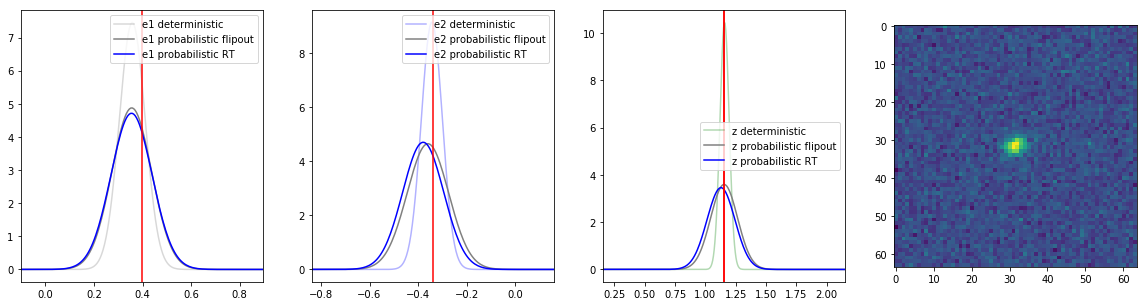

In [70]:
image_nb = 1

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.linspace(-1,5, 1000)

# E1
axes[0].plot(x, (1/(stddevs_without_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e1[0,image_nb])/(2*stddevs_without_e1[0,image_nb]**2))), color = 'grey', alpha = 0.3, label = 'e1 deterministic')

#mean_means = np.mean(means_without_e1[:,image_nb])
#mean_stddevs = np.mean(stddevs_with_e1[:,image_nb])
#axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'e1 deterministic')    

mean_means_prob = np.mean(means_prob_e1[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'e1 probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_e1[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'e1 probabilistic RT')    


axes[0].axvline(test_labels[image_nb,0], color = 'r')

# E2
axes[1].plot(x, (1/(stddevs_without_e2[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e2[0,image_nb])/(2*stddevs_without_e2[0,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2 deterministic')

#mean_means = np.mean(means_with_e2[:,image_nb])
#mean_stddevs = np.mean(stddevs_with_e2[:,image_nb])
#axes[1].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'e2 deterministic')    

mean_means_prob = np.mean(means_prob_e2[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'e2 probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_e2[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'e2 probabilistic RT')    

axes[1].axvline(test_labels[image_nb,1], color = 'r')

# Redshift
axes[2].plot(x, (1/(stddevs_without_z[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_z[0,image_nb])/(2*stddevs_without_z[0,image_nb]**2))), color = 'green', alpha = 0.3, label= 'z deterministic')

#mean_means = np.mean(means_with_z[:,image_nb])
#mean_stddevs = np.mean(stddevs_with_z[:,image_nb])
#axes[2].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label= 'z deterministic')    

mean_means_prob = np.mean(means_prob_z[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'z probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_z[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'z probabilistic RT')    

axes[2].axvline(test_labels[image_nb,2], color = 'r')

# Limit of graphs
axes[0].set_xlim(test_labels[image_nb,0]-0.5,test_labels[image_nb,0]+0.5)
axes[1].set_xlim(test_labels[image_nb,1]-0.5,test_labels[image_nb,1]+0.5)
axes[2].set_xlim(test_labels[image_nb,2]-1,test_labels[image_nb,2]+1)

axes[3].imshow(test_data[image_nb,:,:,2])
axes[0].legend()
axes[1].legend()
axes[2].legend()

#print('e1: '+str(test_labels[image_nb,0]), 'e0: '+str(test_labels[image_nb,1]),'redshift: ' +str(test_labels[image_nb,2]))

#mean_means = np.mean(means_with_z[:,image_nb])
#mean_stddevs = np.mean(stddevs_with_z[:,image_nb])
#axes[2].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label= 'z deterministic')    

#mean_means_prob = np.mean(means_prob_z[:,image_nb])
#mean_stddevs_prob = np.mean(stddevs_prob_z[:,image_nb])
#axes[2].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'z probabilistic flipout')    

#mean_means_prob_rt = np.mean(means_prob_rt_z[:,image_nb])
#mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_z[:,image_nb])
#axes[2].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'z probabilistic RT')    

axes[2].axvline(test_labels[image_nb,2], color = 'r')

# Limit of graphs
axes[0].set_xlim(test_labels[image_nb,0]-0.5,test_labels[image_nb,0]+0.5)
axes[1].set_xlim(test_labels[image_nb,1]-0.5,test_labels[image_nb,1]+0.5)
axes[2].set_xlim(test_labels[image_nb,2]-1,test_labels[image_nb,2]+1)

axes[3].imshow(test_data[image_nb,:,:,2])
axes[0].legend()
axes[1].legend()
axes[2].legend()

print('e1: '+str(test_labels[image_nb,0]), 'e0: '+str(test_labels[image_nb,1]),'redshift: ' +str(test_labels[image_nb,2]))

In [ ]:
image_nb = 2

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.linspace(-1,5, 1000)

# E1
#axes[0].plot(x, (1/(stddevs_without_e1[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e1[0,image_nb])/(2*stddevs_without_e1[0,image_nb]**2))), color = 'grey', alpha = 0.3, label = 'e1 with ls')

mean_means = np.mean(means_with_e1[:,image_nb])
mean_stddevs = np.mean(stddevs_with_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'e1 deterministic')    

mean_means_prob = np.mean(means_prob_e1[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'e1 probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_e1[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_e1[:,image_nb])
axes[0].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'e1 probabilistic RT')    


axes[0].axvline(test_labels[image_nb,0], color = 'r')

# E2
#axes[1].plot(x, (1/(stddevs_without_e2[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_e2[0,image_nb])/(2*stddevs_without_e2[0,image_nb]**2))), color = 'b', alpha = 0.3, label= 'e2 with ls')

mean_means = np.mean(means_with_e2[:,image_nb])
mean_stddevs = np.mean(stddevs_with_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label = 'e2 deterministic')    

mean_means_prob = np.mean(means_prob_e2[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'e2 probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_e2[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_e2[:,image_nb])
axes[1].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'e2 probabilistic RT')    

axes[1].axvline(test_labels[image_nb,1], color = 'r')

# Redshift
#axes[2].plot(x, (1/(stddevs_without_z[0,image_nb]*np.sqrt(2*np.pi))*np.exp(-np.square(x-means_without_z[0,image_nb])/(2*stddevs_without_z[0,image_nb]**2))), color = 'green', alpha = 0.3, label= 'z with ls')

mean_means = np.mean(means_with_z[:,image_nb])
mean_stddevs = np.mean(stddevs_with_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means)/(2*mean_stddevs**2))), color = 'green', alpha = 1, label= 'z deterministic')    

mean_means_prob = np.mean(means_prob_z[:,image_nb])
mean_stddevs_prob = np.mean(stddevs_prob_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs_prob*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob)/(2*mean_stddevs_prob**2))), color = 'grey', alpha = 1, label = 'z probabilistic flipout')    

mean_means_prob_rt = np.mean(means_prob_rt_z[:,image_nb])
mean_stddevs_prob_rt = np.mean(stddevs_prob_rt_z[:,image_nb])
axes[2].plot(x, (1/(mean_stddevs_prob_rt*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean_means_prob_rt)/(2*mean_stddevs_prob_rt**2))), color = 'b', alpha = 1, label = 'z probabilistic RT')    

axes[2].axvline(test_labels[image_nb,2], color = 'r')

# Limit of graphs
axes[0].set_xlim(test_labels[image_nb,0]-0.5,test_labels[image_nb,0]+0.5)
axes[1].set_xlim(test_labels[image_nb,1]-0.5,test_labels[image_nb,1]+0.5)
axes[2].set_xlim(test_labels[image_nb,2]-1,test_labels[image_nb,2]+1)

axes[3].imshow(test_data[image_nb,:,:,2])
axes[0].legend()
axes[1].legend()
axes[2].legend()

print('e1: '+str(test_labels[image_nb,0]), 'e0: '+str(test_labels[image_nb,1]),'redshift: ' +str(test_labels[image_nb,2]))